11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Instructions for updating:
non-resource variables are not supported in the long term
Instructions for updating:

Future major versions of TensorFlow will allow gradients to flow
into the labels input on backprop by default.

See `tf.nn.softmax_cross_entropy_with_logits_v2`.



Iter : 0
Train Loss : 2.5440099239349365
Cost : 2.4590368270874023
Iter : 250
Train Loss : 0.6201913356781006
Cost : 0.4713420867919922
Iter : 500
Train Loss : 0.3608790934085846
Cost : 0.246348574757576
Iter : 750
Train Loss : 0.16552278399467468
Cost : 0.15829701721668243
Iter : 1000
Train Loss : 0.11594630032777786
Cost : 0.391398161649704
Iter : 1250
Train Loss : 0.2743023633956909
Cost : 0.33528536558151245
Iter : 1500
Train Loss : 0.05750589817762375
Cost : 0.1245361864566803
Iter : 1750
Train Loss : 0.14775066077709198
Cost : 0.2103595733642578
Iter : 2000
Train Loss : 0.24831563234329224
Cost : 0.16564668715000153
Iter : 2250
Train Loss : 0.01641341671347618
Cost : 0.06521276384592056


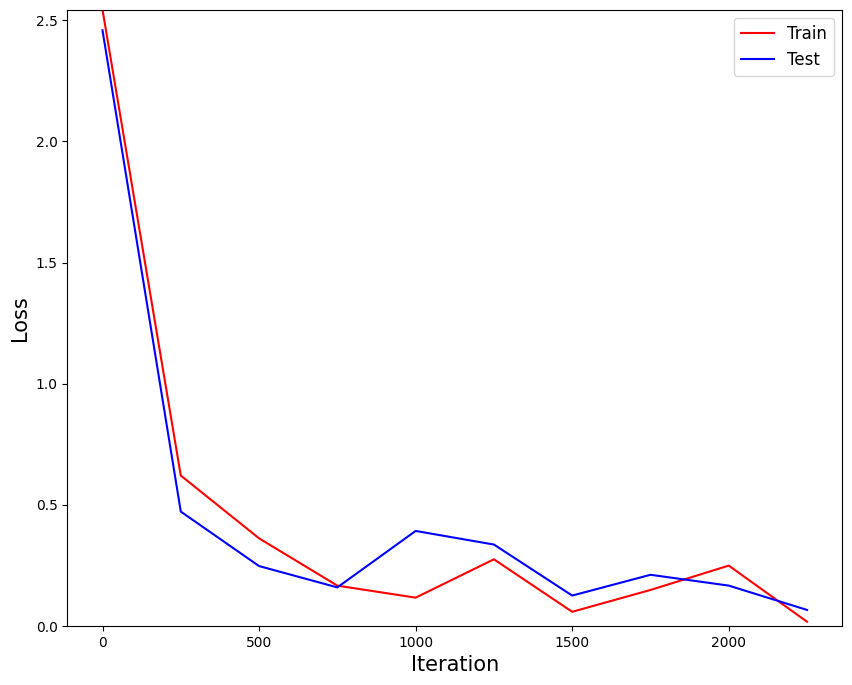

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


mnist = tf.keras.datasets.mnist

(train_x, train_y), (test_x, test_y) = mnist.load_data()

train_x, test_x = train_x/255.0, test_x/255.0
train_x = train_x.reshape((train_x.shape[0], 28, 28, 1))
test_x = test_x.reshape((test_x.shape[0], 28, 28, 1))

# input layer
input_h = 28   # input height
input_w = 28   # input width
input_ch = 1   # input channel : Gray scale

# 1st convolution layer
k1_h = 3
k1_w = 3
k1_ch = 32
p1_h = 2
p1_w = 2
# (None, 14, 14, 32)

# 2nd convolution layer
k2_h = 3
k2_w = 3
k2_ch = 64
p2_h = 2
p2_w = 2
# (None, 7, 7, 64)

# Fully connected : flatten the features (7x7x64)
conv_result_size = 64
n_hidden = 100
n_output = 10
# Kernel size : [kernel_height, kernel_width, input_ch, output_ch]
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

weights = {
    'conv1' : tf.Variable(tf.random.normal([3,3,1,32], stddev = 0.1)),
    'conv2' : tf.Variable(tf.random.normal([3,3,32,64], stddev = 0.1)),
    'hidden' : tf.Variable(tf.random.normal([7*7*64,100], stddev = 0.1)),
    'output' : tf.Variable(tf.random.normal([100,10], stddev = 0.1))
}
# bias size : [output_ch] or [neuron_size]
biases = {
    'conv1' : tf.Variable(tf.random.normal([32], stddev = 0.1)),
    'conv2' : tf.Variable(tf.random.normal([64], stddev = 0.1)),
    'hidden' : tf.Variable(tf.random.normal([100], stddev = 0.1)),
    'output' : tf.Variable(tf.random.normal([10], stddev = 0.1))
}

# input layer : [batch_size, image_height, image_width, channels]
# output layer : [batch_size, class_size]
x = tf.placeholder(shape=[None, input_h, input_w, input_ch], dtype=tf.float32)
y = tf.placeholder(shape=[None, n_output], dtype=tf.float32)

# [batch, height, width, channels]
def net(x, weights, biases):
    # 1st convolution layer
    conv1 = tf.nn.conv2d(x, weights['conv1'], strides=[1,1,1,1], padding = 'SAME')
    conv1 = tf.nn.relu(tf.add(conv1, biases['conv1']))
    maxp1 = tf.nn.max_pool(conv1, ksize=[1,2,2,1], strides=[1,2,2,1], padding= 'VALID')
#   maxp1 = tf.nn.max_pool(conv1, ksize=[1,p1_h,p1_w,1], strides=[1,p1_h,p1_w,1], padding='VALID')

    # 2nd convolution layer
    conv2 = tf.nn.conv2d(maxp1, weights['conv2'], strides=[1,1,1,1], padding = 'SAME')
    conv2 = tf.nn.relu(tf.add(conv2, biases['conv2']))
    maxp2 = tf.nn.max_pool(conv2, ksize=[1,2,2,1], strides=[1,2,2,1], padding = 'VALID')

    maxp2_flatten = tf.reshape(maxp2, [-1, 7*7*64])

    # Fully connected
    hidden = tf.add(tf.matmul(maxp2_flatten, weights['hidden']), biases['hidden'])
    hidden = tf.nn.relu(hidden)
    output = tf.add(tf.matmul(hidden, weights['output']), biases['output'])

    return output


# Loss function

LR = 0.0001
pred = net(x, weights, biases)
loss = tf.nn.softmax_cross_entropy_with_logits(logits = pred, labels=y)
loss = tf.reduce_mean(loss)

optm = tf.train.AdamOptimizer(learning_rate=LR).minimize(loss)

# Optimization

n_batch = 50
n_iter = 2500
n_prt = 250

sess = tf.Session()
sess.run(tf.global_variables_initializer())

loss_record_train = []
loss_record_test = []
for epoch in range(n_iter):
    # Get a random batch of training data
  batch_indices = np.random.choice(train_x.shape[0], size=n_batch, replace=False)
  batch_x = train_x[batch_indices]
  batch_y = train_y[batch_indices]

  batch_x = np.reshape(batch_x, (-1, 28, 28, 1))
  # batch_x = np.reshape(batch_x, (n_batch, input_h, input_w, input_ch))
  # Convert labels to one-hot encoding if necessary
  batch_y_onehot = tf.keras.utils.to_categorical(batch_y, num_classes=10)  # Adjust num_classes if needed
  batch_y_onehot = batch_y_onehot.astype(np.float32)

  sess.run(optm, feed_dict={x:batch_x, y:batch_y_onehot})

  if epoch % n_prt == 0:

        # Get a random batch of test data
      test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
      test_batch_x = test_x[test_batch_indices]
      test_batch_y = test_y[test_batch_indices]

      test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))

        # Convert labels to one-hot encoding if necessary
      test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed
      test_batch_y = test_batch_y.astype(np.float32)
      c1 = sess.run(loss, feed_dict={x: batch_x, y: batch_y_onehot})
      c2 = sess.run(loss, feed_dict={x: test_batch_x, y: test_batch_y})

      loss_record_train.append(c1)
      loss_record_test.append(c2)
      print("Iter : {}".format(epoch))
      print("Train Loss : {}".format(c1))
      print("Cost : {}".format(c2))

plt.figure(figsize = (10,8))
plt.plot(np.arange(len(loss_record_train))*n_prt, loss_record_train, 'r', label = 'Train')
plt.plot(np.arange(len(loss_record_test))*n_prt, loss_record_test, 'b', label = 'Test')
plt.xlabel('Iteration', fontsize = 15)
plt.ylabel('Loss', fontsize = 15)
plt.legend(fontsize = 12)
plt.ylim([0, np.max(loss_record_train)])
plt.show()







In [3]:
# Evaluation
# Get a random batch of test data
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]

test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))  # Reshape the batch if needed
# Convert labels to one-hot encoding if necessary
test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed

my_pred = sess.run(pred, feed_dict={x: test_batch_x.reshape(-1, 28, 28, 1)})
my_pred = np.argmax(my_pred, axis=1)

labels = np.argmax(test_batch_y, axis=1)

accr = np.mean(np.equal(my_pred, labels))
print("Accuracy : {}".format(accr*100))

Accuracy : 96.0


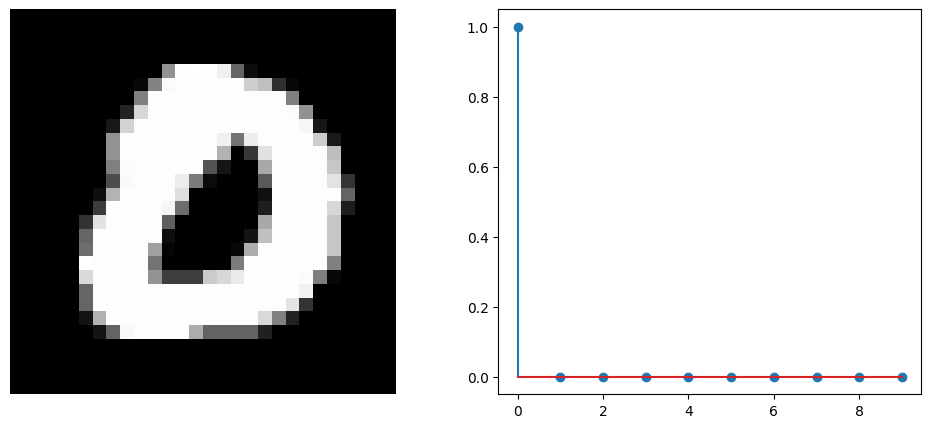

Prediction : 0
Probability : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [4]:
# Get a random batch of test data
n_batch = 1
test_batch_indices = np.random.choice(test_x.shape[0], size=n_batch, replace=False)
test_batch_x = test_x[test_batch_indices]
test_batch_y = test_y[test_batch_indices]

test_batch_x = test_batch_x.reshape((n_batch, input_h, input_w, input_ch))  # Reshape the batch if needed
# Convert labels to one-hot encoding if necessary
test_batch_y = tf.keras.utils.to_categorical(test_batch_y, num_classes=10)  # Adjust num_classes if needed

logits = sess.run(tf.nn.softmax(pred), feed_dict={x: test_batch_x.reshape(-1, 28, 28, 1)})
predict = np.argmax(logits)

plt.figure(figsize = (12, 5))
plt.subplot(1,2,1)
plt.imshow(test_batch_x.reshape(28, 28), 'gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.stem(logits.ravel())
plt.show()

np.set_printoptions(precision = 2, suppress = True)
print('Prediction : {}'.format(predict))
print('Probability : {}'.format(logits.ravel()))